In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
#Importing other required modules
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

**Loading data**

In [3]:
train=pd.read_csv('/kaggle/input/titanic/train.csv')
train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
test=pd.read_csv('/kaggle/input/titanic/test.csv')
test.head(3)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


**Handling missing values**

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train['Age'].fillna(train['Age'].mean(),inplace=True)

In [7]:
train['Embarked'].fillna('S',inplace=True)

In [8]:
train['Embarked'].mode()

0    S
dtype: object

In [9]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [10]:
#Deleting cabin column as more then 50% data is missing
train.drop('Cabin',axis=1,inplace=True)

**TRAIN DATA IS CLEANED**

**Handling missigng values in test data the same way**

In [11]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [12]:
test['Age'].fillna(test['Age'].mean(),inplace=True)

In [13]:
test['Fare'].fillna(test['Fare'].mean(),inplace=True)

In [14]:
test.drop('Cabin',axis=1,inplace=True)

In [15]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

**TEST DATA IS CLEANED**

# EDA ON TRAIN DATA

In [16]:
train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.000000,891,891.000000,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,646
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,13.002015,1.102743,0.806057,NaN,49.693429,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.000000,NaN,7.910400,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,29.699118,0.000000,0.000000,NaN,14.454200,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.000000,NaN


**Removing unnecessary or noise columns from our data for better model accuracy**

In [17]:
train.drop(['PassengerId','Name'],axis=1,inplace=True)

In [18]:
train.drop('Ticket',axis=1,inplace=True)

**Feature engineering**

In [19]:
train['Family-members']=train['SibSp']+train['Parch']

In [20]:
train.drop(['SibSp','Parch'],axis=1,inplace=True)

In [21]:
train.sample(4)

,Survived,Pclass,Sex,Age,Fare,Embarked,Family-members
154,0,3,male,29.699118,7.3125,S,0
207,1,3,male,26.000000,18.7875,C,0
544,0,1,male,50.000000,106.4250,C,1
763,1,1,female,36.000000,120.0000,S,3


In [22]:
train['survived']=train['Survived']

In [23]:
train.drop('Survived',axis=1,inplace=True)

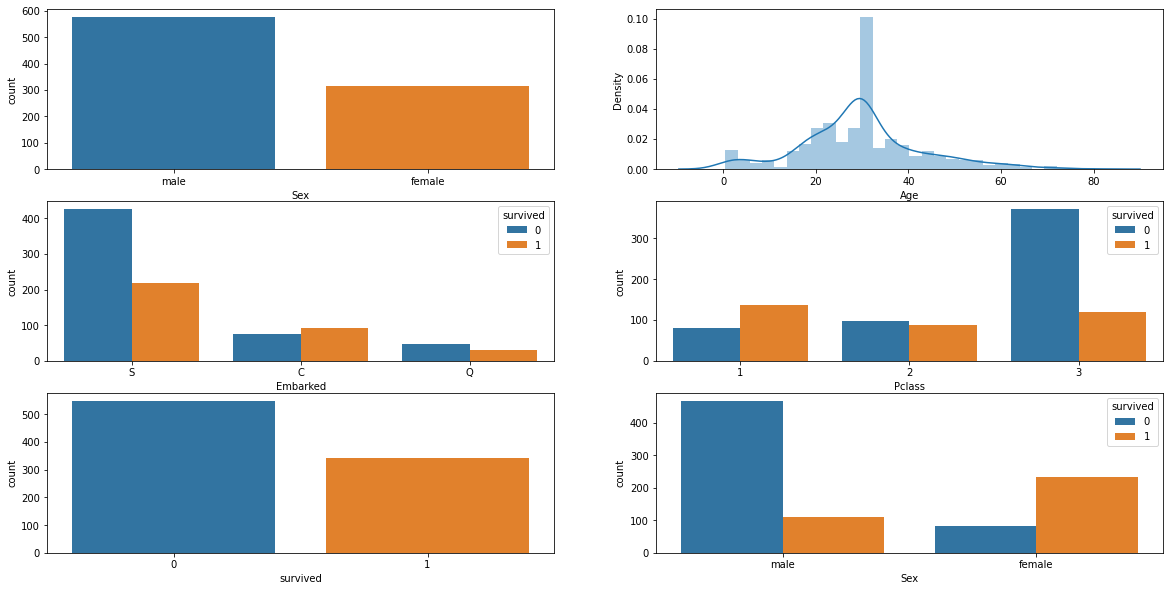

In [24]:
plt.figure(1,figsize=(20,10))

plt.subplot(3,2,1)
sns.countplot(train['Sex'])

plt.subplot(3,2,2)
sns.distplot(train['Age'])

plt.subplot(3,2,3)
sns.countplot(train['Embarked'],hue=train['survived'])

plt.subplot(3,2,4)
sns.countplot(train['Pclass'],hue=train['survived'])

plt.subplot(3,2,5)
sns.countplot(train['survived'])

plt.subplot(3,2,6)
sns.countplot(train['Sex'],hue=train['survived'])

plt.show()

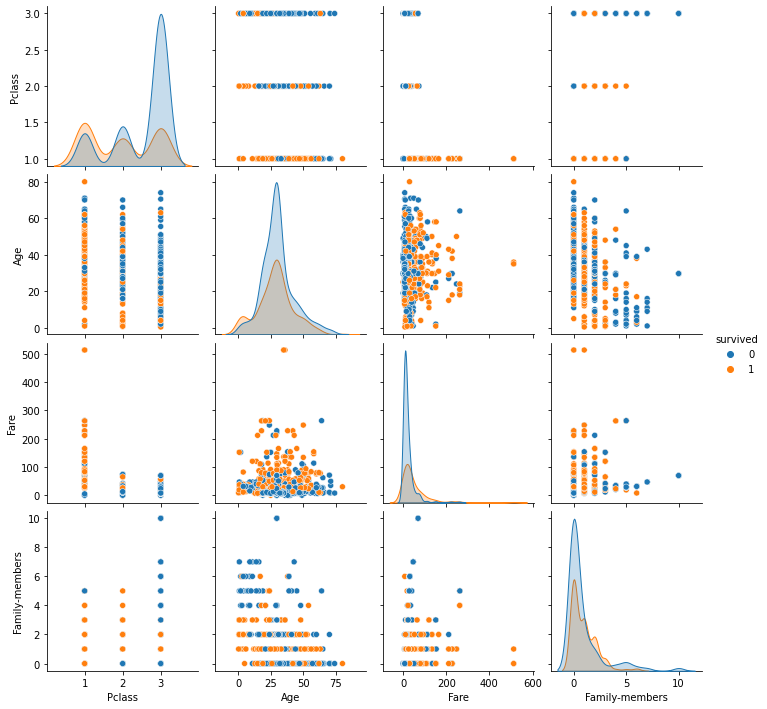

In [25]:
sns.pairplot(train,hue='survived')
plt.show()

**#Encoding our train data to convert into numeric value**

In [26]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()

In [27]:
train[['Sex','Embarked']]=oe.fit_transform(train[['Sex','Embarked']])

In [28]:
train.head(2)

,Pclass,Sex,Age,Fare,Embarked,Family-members,survived
0,3,1.0,22.0,7.2500,2.0,1,0
1,1,0.0,38.0,71.2833,0.0,1,1


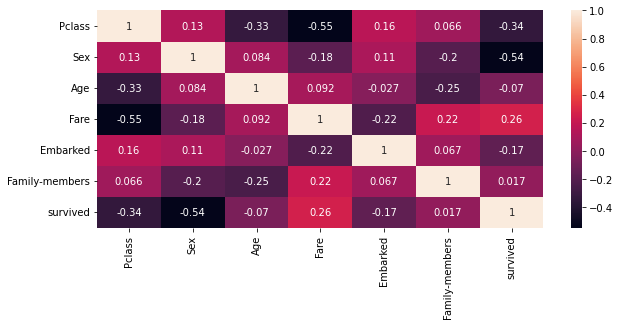

In [29]:
plt.figure(1,figsize=(10,4))
sns.heatmap(train.corr(),annot=True)
plt.show()

From the above heatmap we can observe that our features are not quite correlated to target, except for sex and pclass which has negative correlation

**Following the same EDA on test data for model**

In [30]:
test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [31]:
test['Family-members']=test['SibSp']+test['Parch']

In [32]:
test.drop(['PassengerId','Name','Ticket','SibSp','Parch','Ticket'],axis=1,inplace=True)

In [33]:
test.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Family-members'], dtype='object')

In [34]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pclass          418 non-null    int64  
 1   Sex             418 non-null    object 
 2   Age             418 non-null    float64
 3   Fare            418 non-null    float64
 4   Embarked        418 non-null    object 
 5   Family-members  418 non-null    int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 19.7+ KB


In [35]:
test[['Sex','Embarked']]=oe.fit_transform(test[['Sex','Embarked']])

# Vertically Spliting our train data into features and target

In [36]:
x=train.iloc[:,:-1]#Features
y=train.iloc[:,-1]#Target

# Horizontally Spliting our features and target to train our model

In [37]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=1,test_size=0.2)

# KNeighborClassification model

In [38]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

# Accuracy

In [39]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
acc=accuracy_score(ytest,ypred)
cm=confusion_matrix(ytest,ypred)
cr=classification_report(ytest,ypred)
print(f'Accuracy: {acc}\n\n {cm}\n\n {cr}')

Accuracy: 0.7150837988826816

 [[90 16]
 [35 38]]

               precision    recall  f1-score   support

           0       0.72      0.85      0.78       106
           1       0.70      0.52      0.60        73

    accuracy                           0.72       179
   macro avg       0.71      0.68      0.69       179
weighted avg       0.71      0.72      0.71       179



In [40]:
trainAccuracy=knn.score(xtrain,ytrain)
testAccuracy=knn.score(xtest,ytest)
print(f'Training Accuracy: {trainAccuracy} \n Testing Accuracy: {testAccuracy}')

Training Accuracy: 0.8089887640449438 
 Testing Accuracy: 0.7150837988826816


# Hypertuning to get best K value

In [41]:
trainac=[]
testac=[]
for i in range(1,31):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(xtrain,ytrain)
    
    train=knn.score(xtrain,ytrain)
    test=knn.score(xtest,ytest)
    
    trainac.append(train)
    testac.append(test)

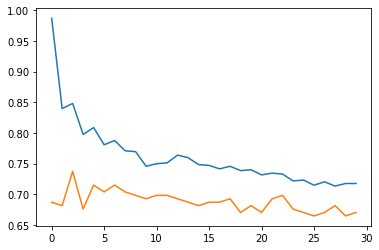

In [42]:
plt.plot(trainac)
plt.plot(testac)
plt.show()

In [43]:
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

In [44]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
acc=accuracy_score(ytest,ypred)
cm=confusion_matrix(ytest,ypred)
cr=classification_report(ytest,ypred)
print(f'Accuracy: {acc}\n\n {cm}\n\n {cr}')

Accuracy: 0.7150837988826816

 [[91 15]
 [36 37]]

               precision    recall  f1-score   support

           0       0.72      0.86      0.78       106
           1       0.71      0.51      0.59        73

    accuracy                           0.72       179
   macro avg       0.71      0.68      0.69       179
weighted avg       0.71      0.72      0.70       179



In [45]:
trainAccuracy=knn.score(xtrain,ytrain)
testAccuracy=knn.score(xtest,ytest)
print(f'Training Accuracy: {trainAccuracy} \n Testing Accuracy: {testAccuracy}')

Training Accuracy: 0.7879213483146067 
 Testing Accuracy: 0.7150837988826816
